# Bosques Aleatorios

### Bosques Aleatorios: ¿Ingreso Alto o Bajo?

* Imagenemos que tenemos el siguiente arbol de decisión, el cuál clasifica tu ingreso en base a las horas trabajadas, años de estudio, Edad, Tipo, Trabajo.
* En el segundo arbol tiene más nodos y más factores de decisión, por lo que tendrá más hojas.
* Los 3 árboles podrían llegar a ser más correctos que otros, ¿a que árbok deberíamos escoger?
* Los bosques buscan la mayor variabilidad.

![ArbolDecision.png](ArbolDecision.png) ![ArbolDecision2.png](ArbolDecision2.png)
![ArbolDecision3.png](ArbolDecision3.png)

* Random Forest es un algoritmo de aprendizaje supervisado basado en un conjunto (ensemble) de árboles de decisión.
* La idea es combinar muchos árboles simples para crear un modelo más robusto y preciso.
* `Bootstrap Sampling`: De los datos originales, se generan muestras aleatorias con reemplazo. Cada muestra se usa para entrenar un árbol de decisión independiente.
* `Selección aleatoria de características`: En cada nodo del árbol, no se consideran todas las variables para dividir, sino solo un subconjunto aleatorio. Esto introduce diversidad entre árboles.
* `Agregación de resultados`:
  - Clasificación → votación mayoritaria entre árboles.
  - Regresión → promedio de las predicciones.
* La calidad de una división se evalúa con un criterio como impureza Gini o entropía.

* Ventajas
  - ✅ Robusto al overfitting (mejor que un solo árbol).
  - ✅ Puede manejar datos con muchas variables.
  - ✅ Funciona bien incluso con valores faltantes.
  - ✅ Soporta clasificación y regresión.

* Desventajas
  - ❌ Difícil de interpretar comparado con un árbol único.
  - ❌ Puede ser más lento si n_estimators es muy grande.
  - ❌ Ocupa más memoria.



### Aleatoridad

* Muestreo con reemplazo "max_samples"
* Técnica Boostrap
* En este sample, se puede repetir columnas.
* Esta técnica prodía permitir crear diferentes bosques aleatorios

In [3]:
import pandas as pd

personas = pd.read_csv("ingresos.csv")
print(personas.sample(frac=2/3, replace=True))
print(personas.sample(frac=2/3, replace=True))
print(personas.sample(frac=2/3, replace=True))

    edad  estudio  genero  tipo_trabajo  horas  ingreso
82    49        9       1             0     40        0
13    58        9       0             0     40        0
96    20       10       0             0     25        0
14    34       13       1             1     55        0
28    30        9       1             1     60        0
..   ...      ...     ...           ...    ...      ...
82    49        9       1             0     40        0
83    36       10       1             0     55        1
38    47        9       1             0     40        0
9     41       10       1             0     40        1
69    40        9       0             0     40        0

[67 rows x 6 columns]
    edad  estudio  genero  tipo_trabajo  horas  ingreso
84    66        7       1             0     40        0
50    20       10       0             0     40        0
81    34       10       0             1     72        0
5     20       10       1             0     40        0
95    32       13       1

### Aleatoriedad: Selección de Características para Divisiones

* max_features = sqrt(num_características)
* `print(personas.columns[:-1], '\n')` este simplemente es para ignorar la variable objetivo "ingresos".
* Por ultimo escogemos solo 3 de las columnas objetivos.

In [5]:
from random import sample

print(personas.columns[:-1], '\n')
print(sample(sorted(personas.columns[:-1]), 3))

Index(['edad', 'estudio', 'genero', 'tipo_trabajo', 'horas'], dtype='object') 

['tipo_trabajo', 'estudio', 'edad']


### Creación de Bosque Aleatorio (Random Forest)

* `n_estimators=100`: cuantos arboles serán tomados en cuenta. 100 diferenteses arboles, también este es el parametro estandar.
* `criterion="gini"`: criterio de creación de los arboles,también se puede usar el entropy.
* `max_features="sqrt"`
* `bootstrap=True`: es para activar un muestro aleatorio.
* `max_samples=2/3,` hacemos el sampleo y guardamos un 1/3 de la data restante
* `oob_score=True`: fuera de la bolsas, no fueron utilizadas para crar el arbol.
* Finalmente entrenamos nuestros arboles y al final comprobamos con los datos de una persona.


***NOTAS***
1. n_estimators → número de árboles.
2. max_features → número máximo de variables consideradas en cada división.
3. max_depth → profundidad máxima de cada árbol.
4. min_samples_split → mínimo de muestras para dividir un nodo.
5. bootstrap → si usar muestreo con reemplazo (normalmente True).

In [6]:
from sklearn.ensemble import RandomForestClassifier

bosque = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    bootstrap=True,
    max_samples=2/3,
    oob_score=True
)

# Tiene que recibir arreglos de numpy, no series de pajd
bosque.fit(personas[personas.columns[:-1]].values, personas["ingreso"].values)

print(bosque.predict([[50,16,1,1,40]]))
print(bosque.score(personas[personas.columns[:-1]].values, personas["ingreso"].values))
print(bosque.oob_score_)

[1]
0.97
0.79


### Visualización del Bosque Aletorio

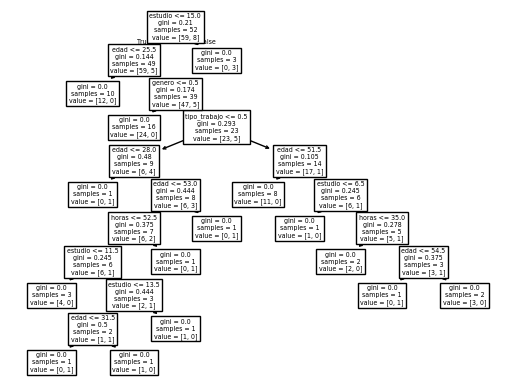

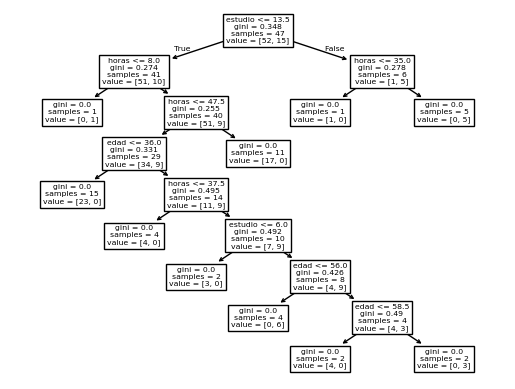

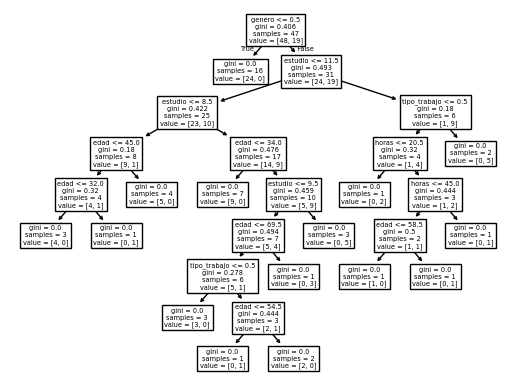

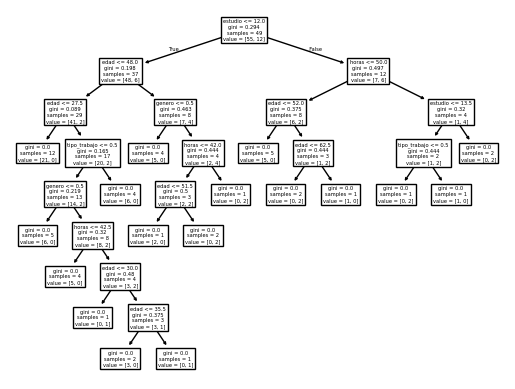

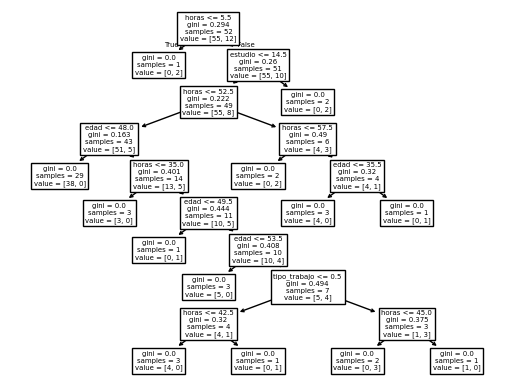

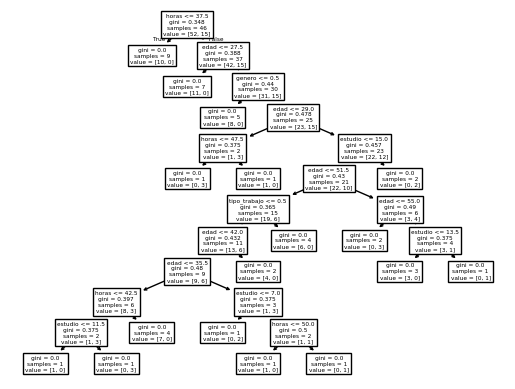

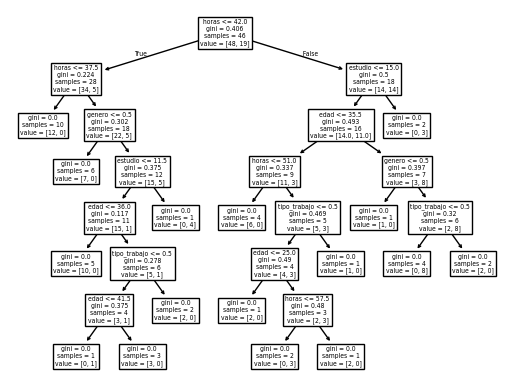

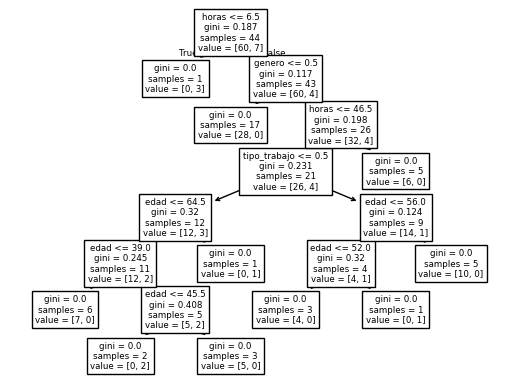

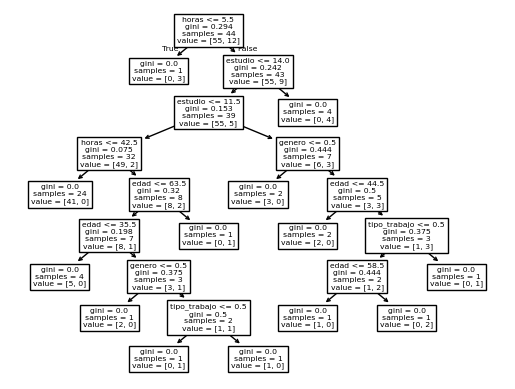

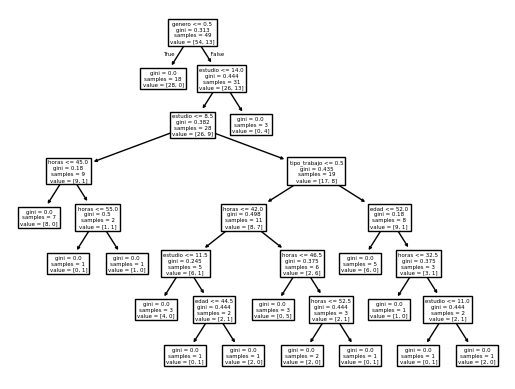

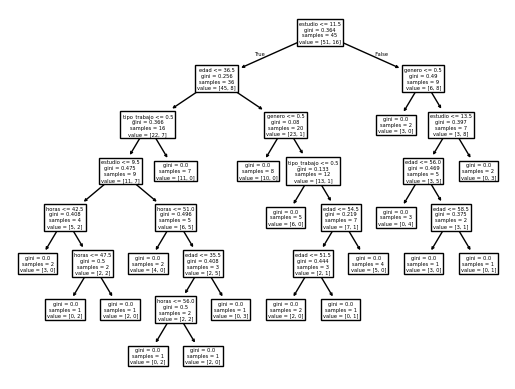

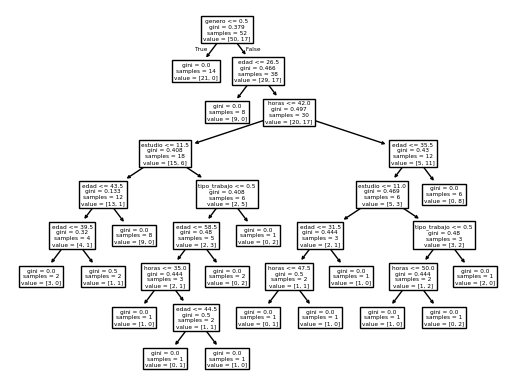

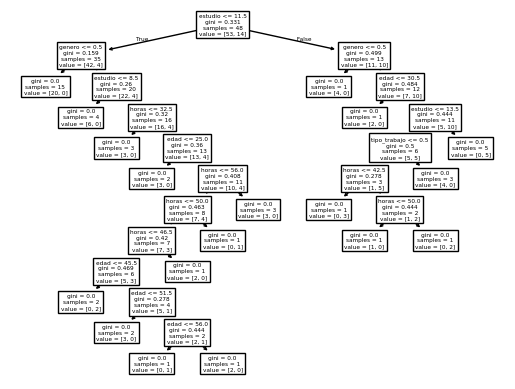

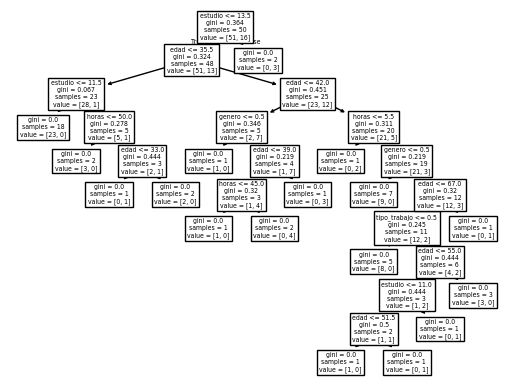

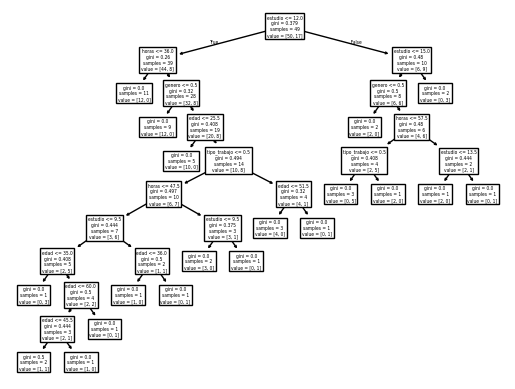

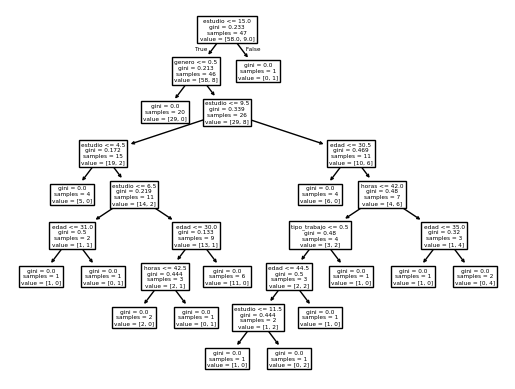

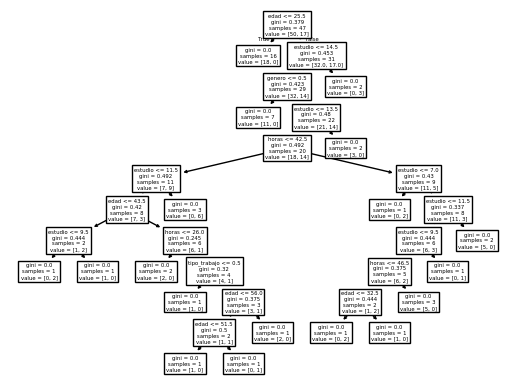

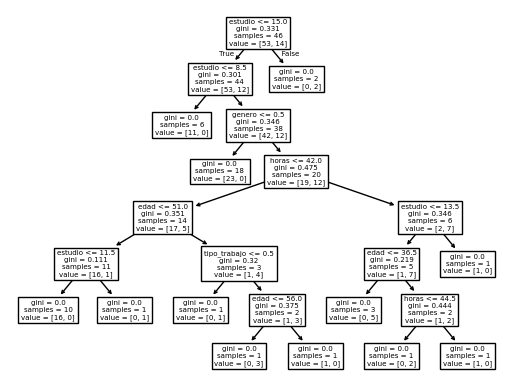

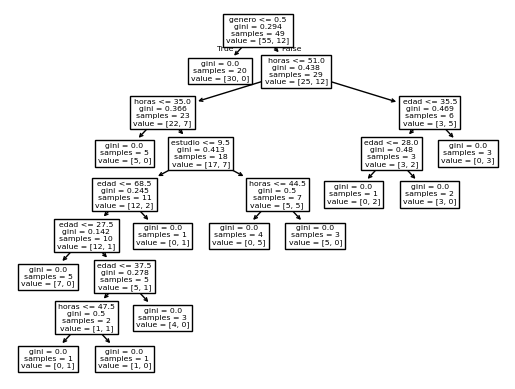

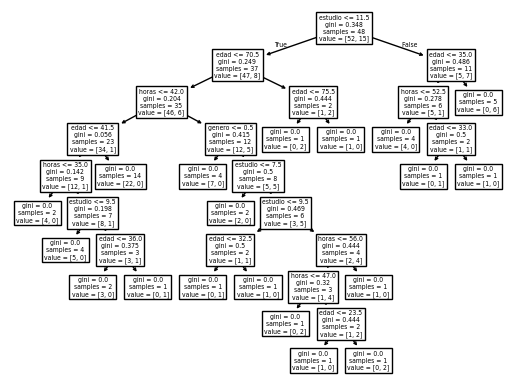

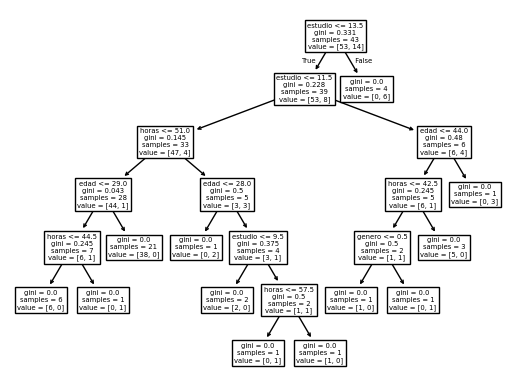

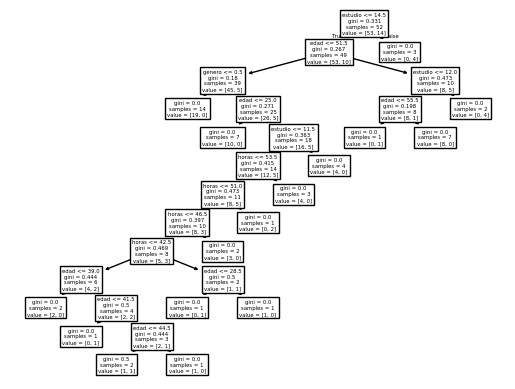

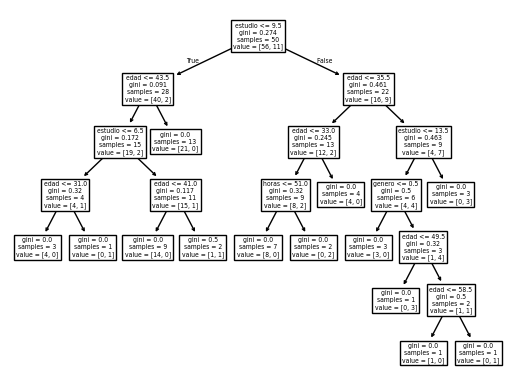

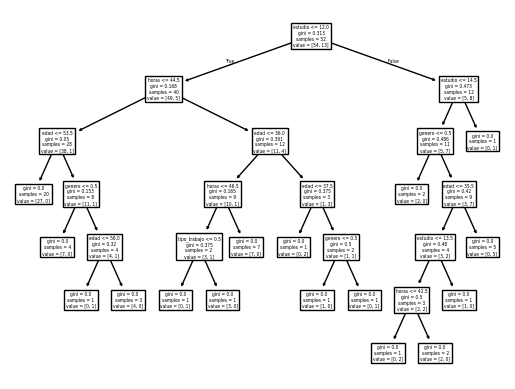

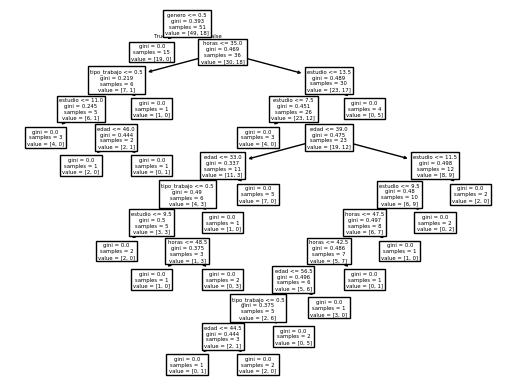

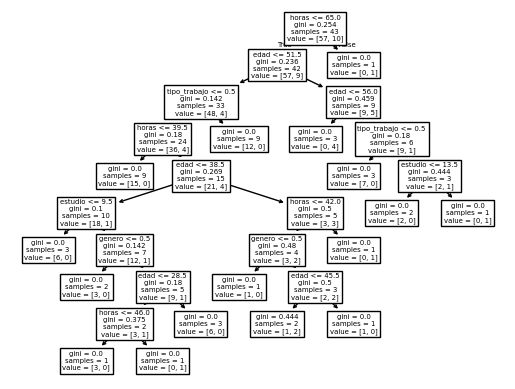

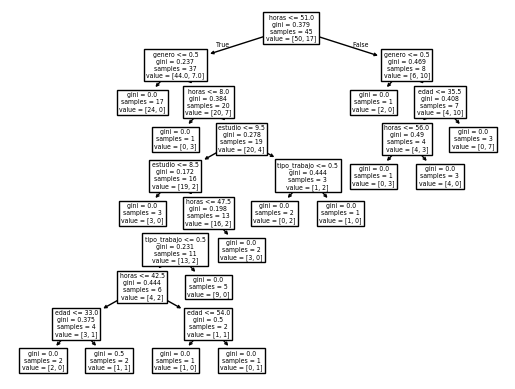

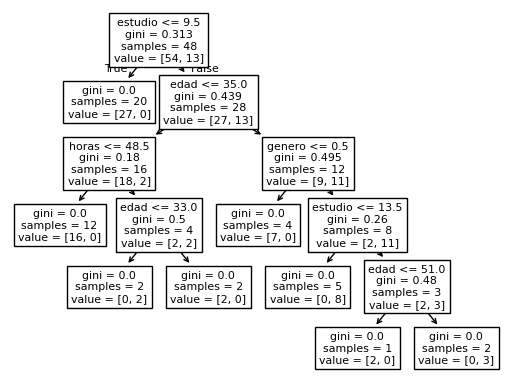

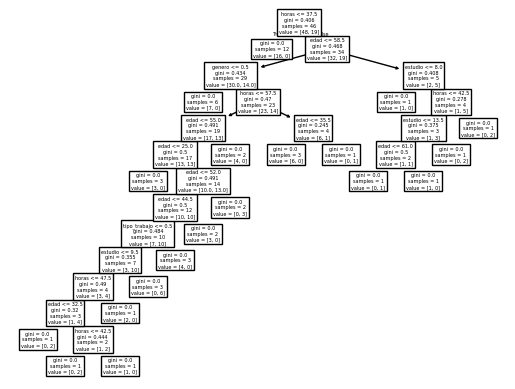

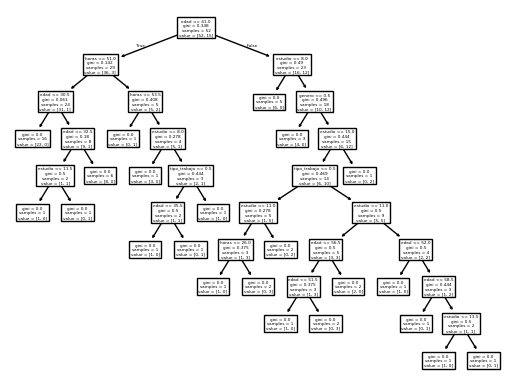

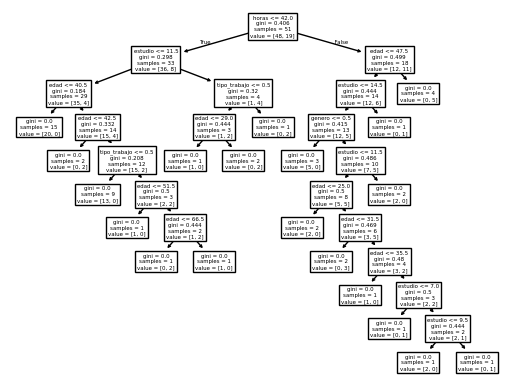

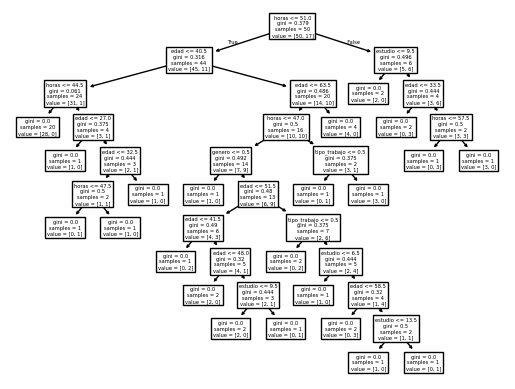

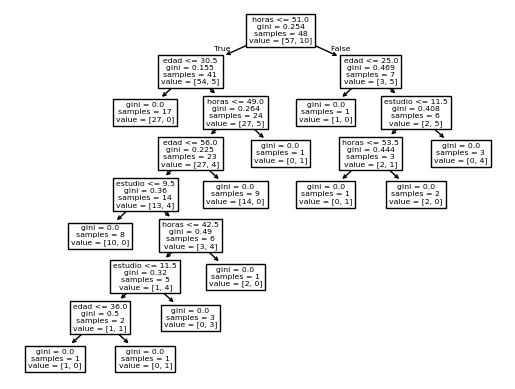

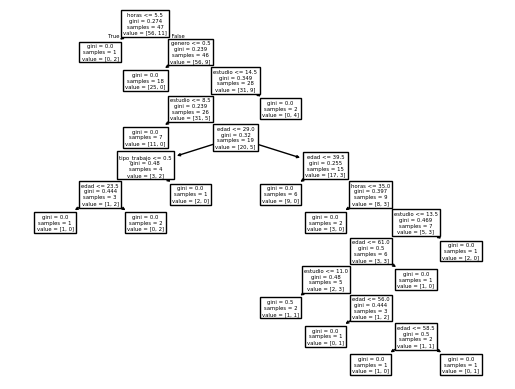

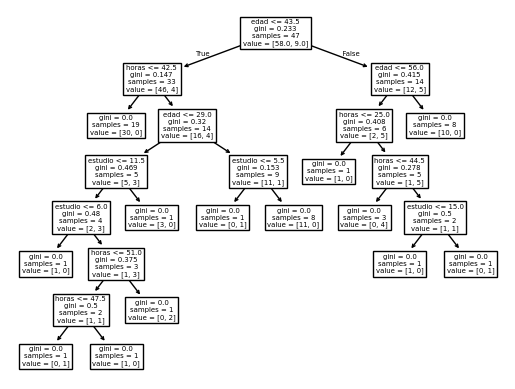

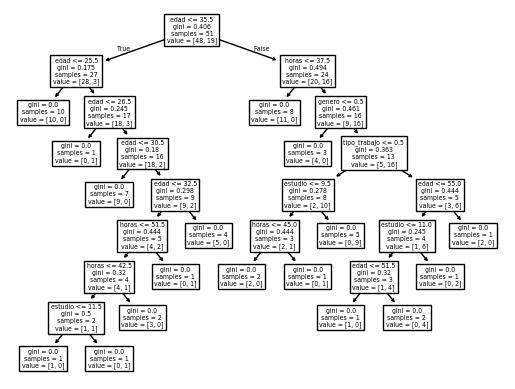

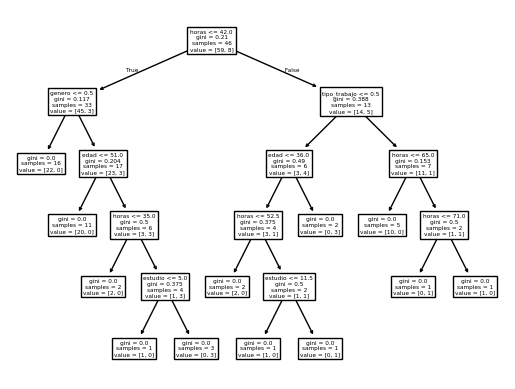

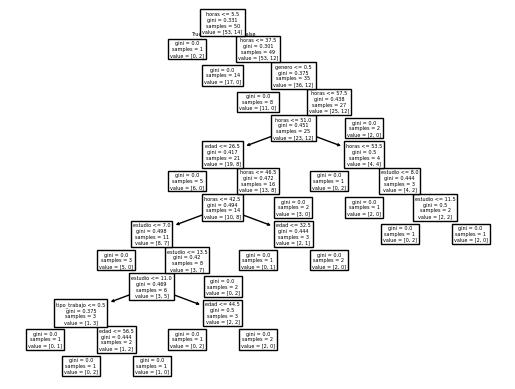

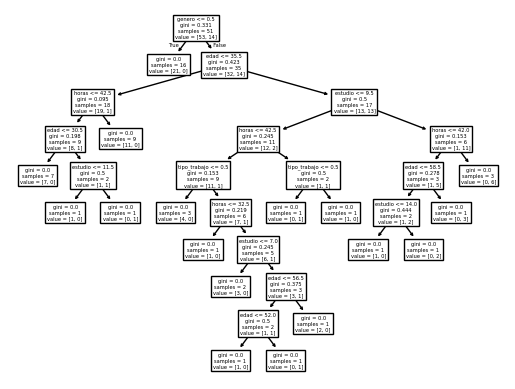

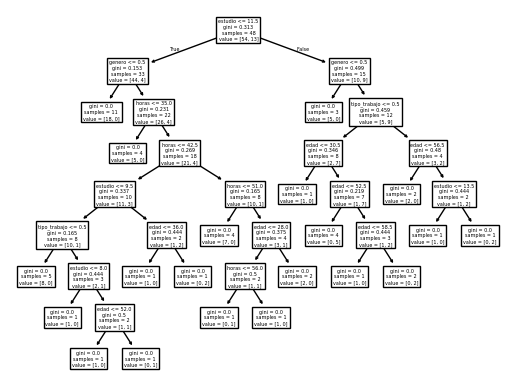

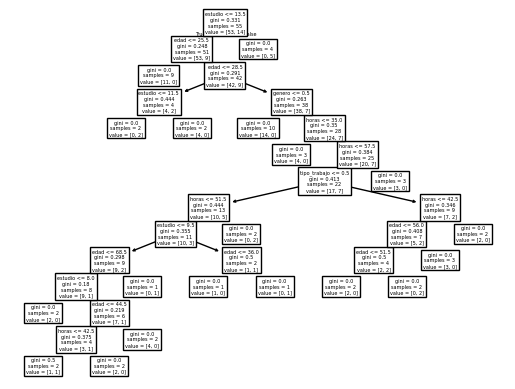

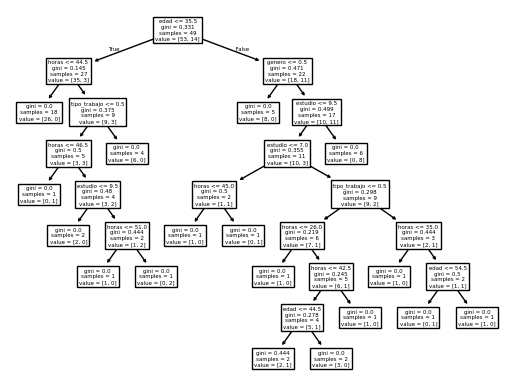

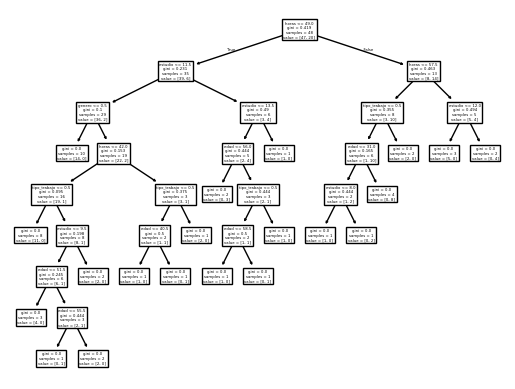

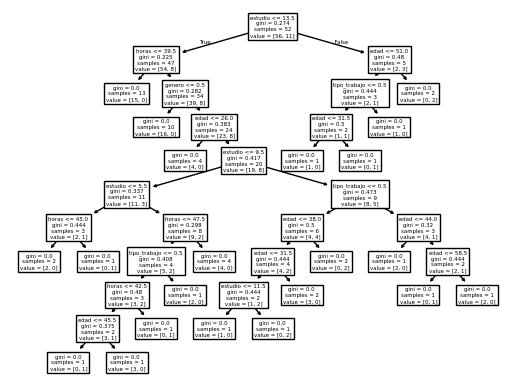

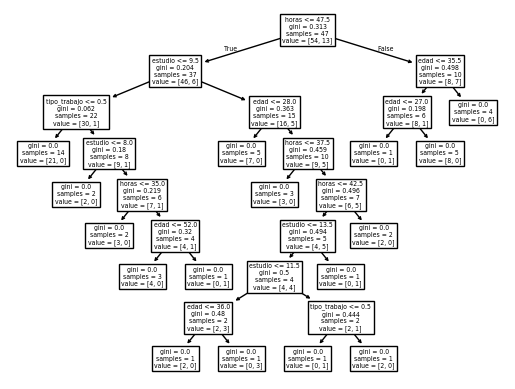

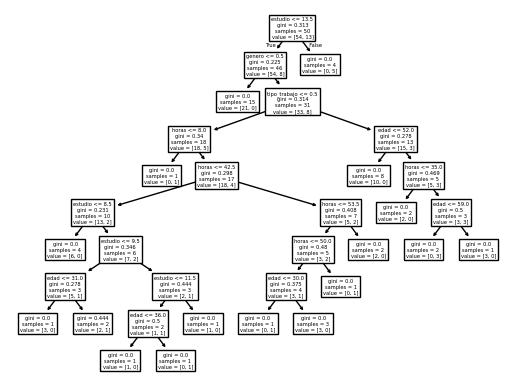

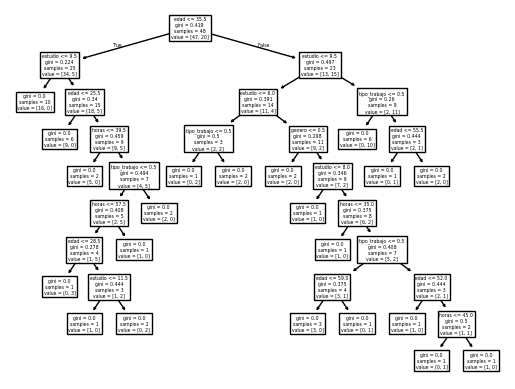

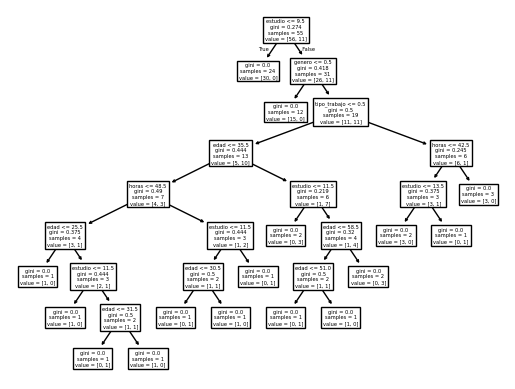

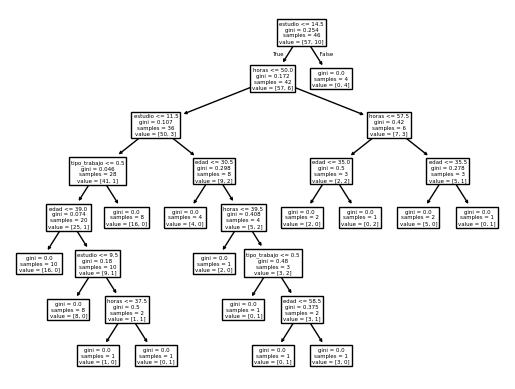

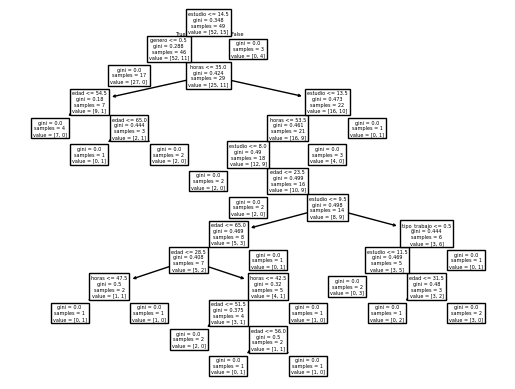

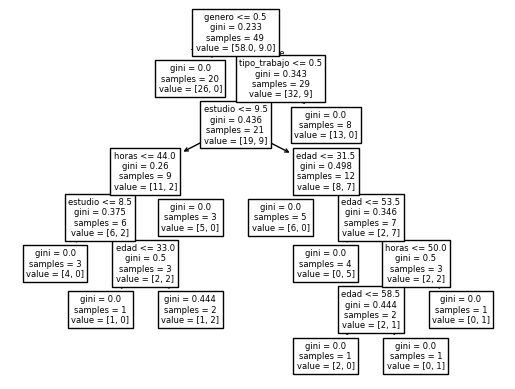

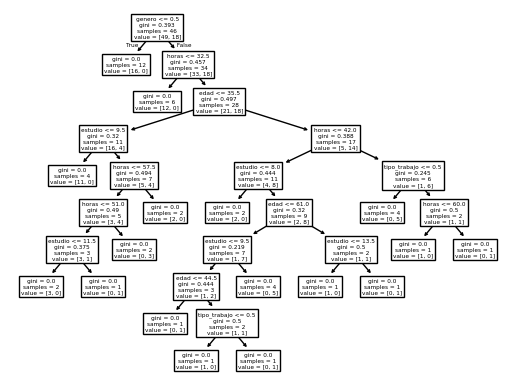

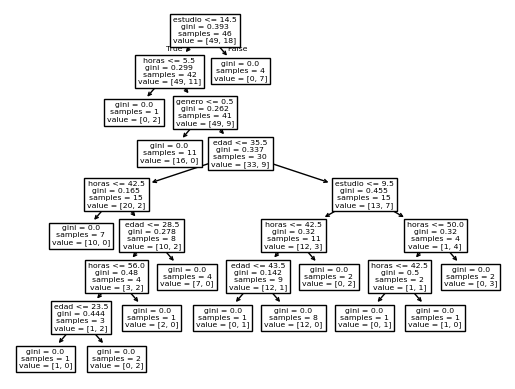

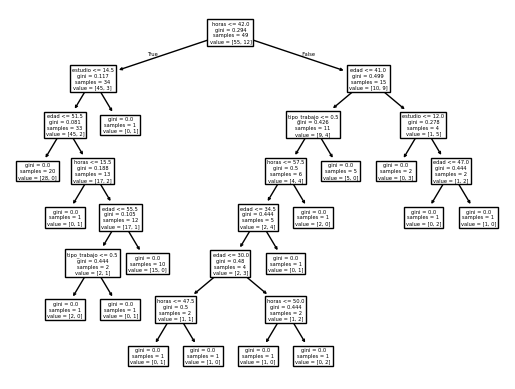

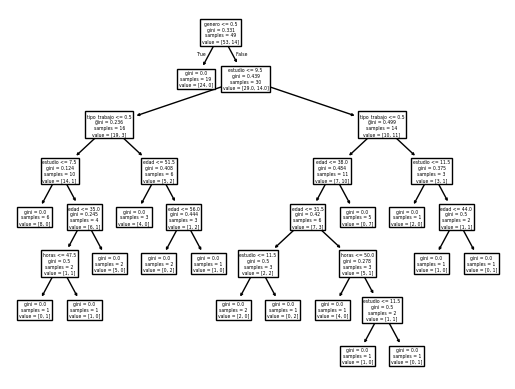

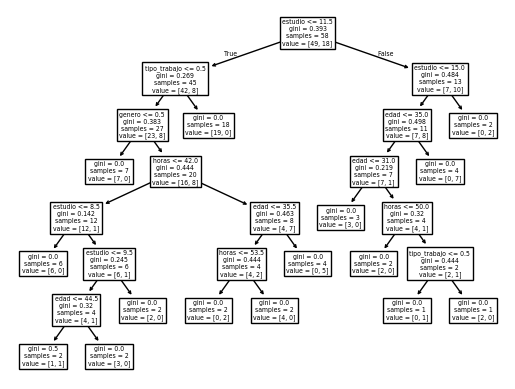

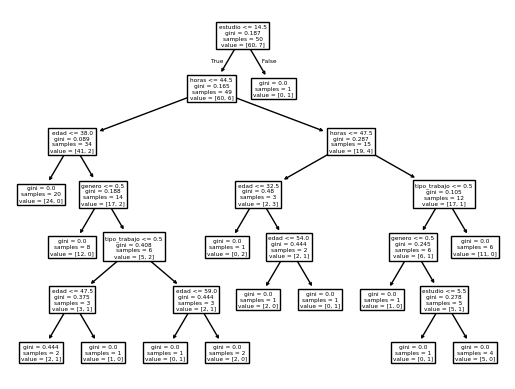

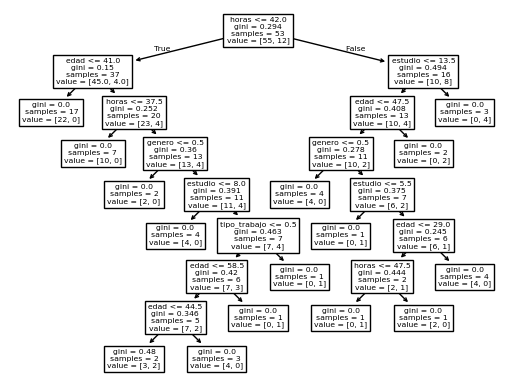

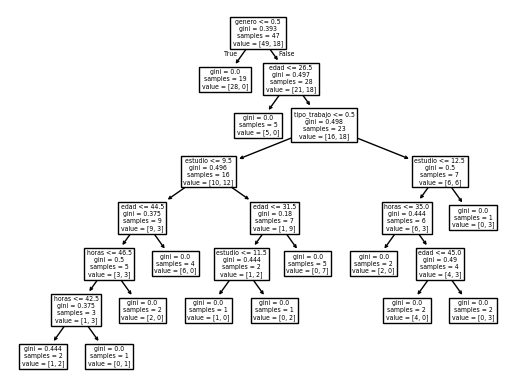

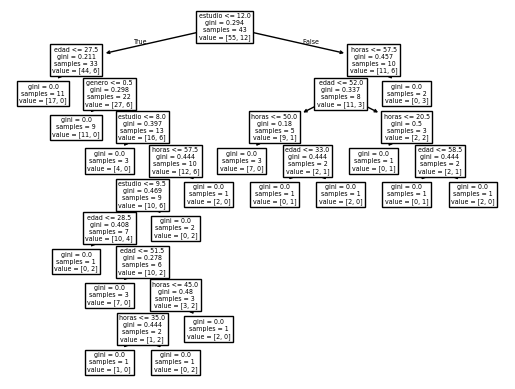

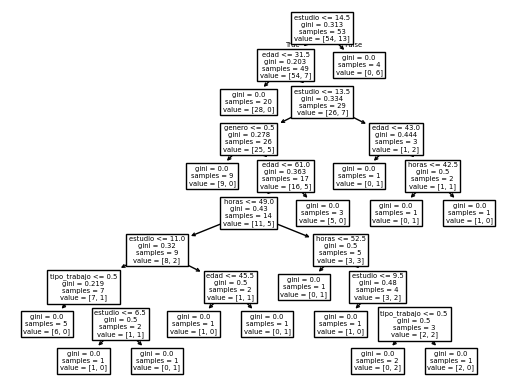

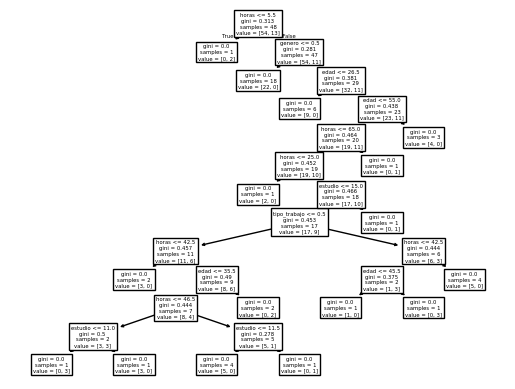

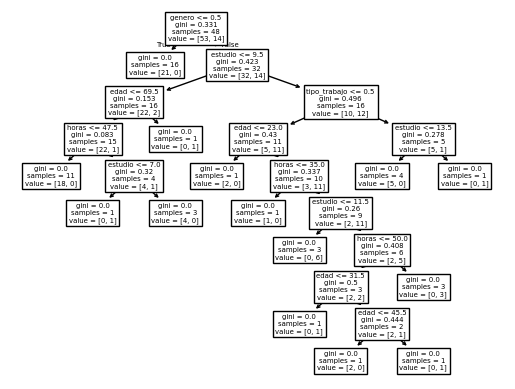

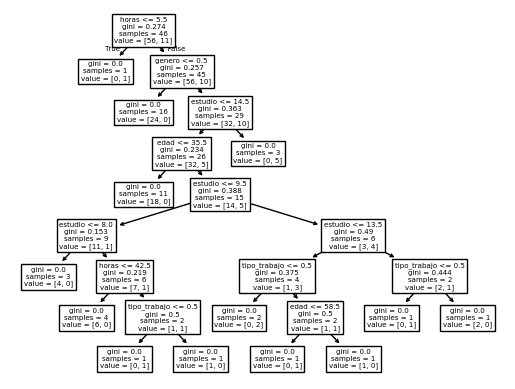

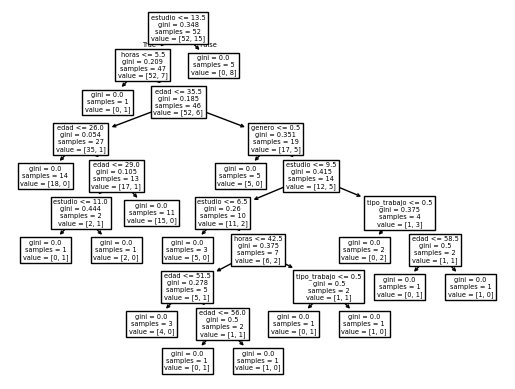

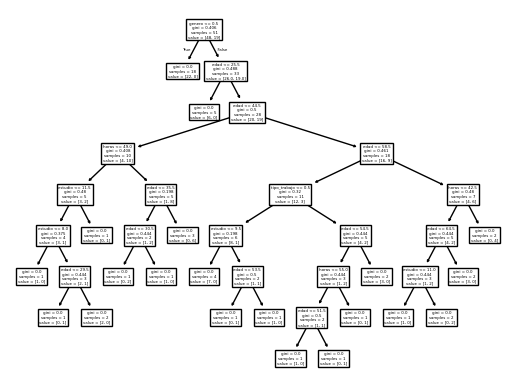

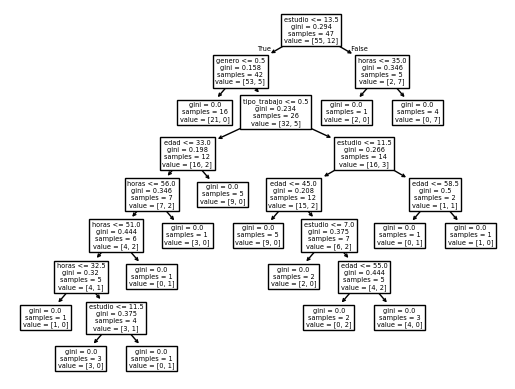

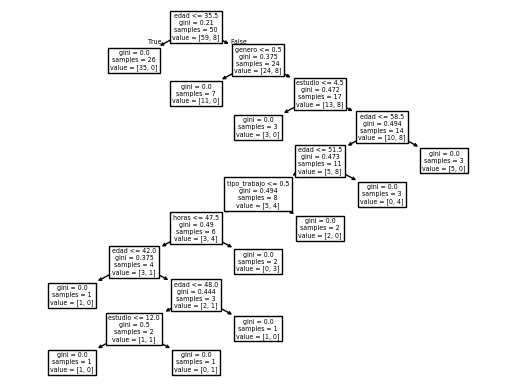

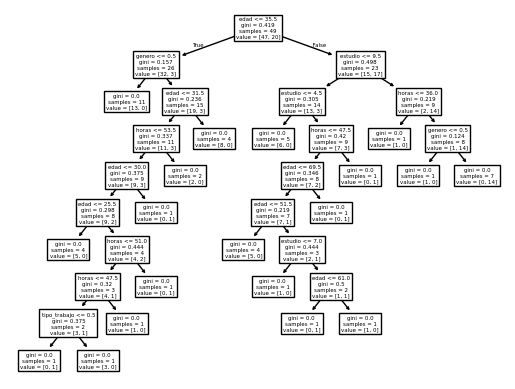

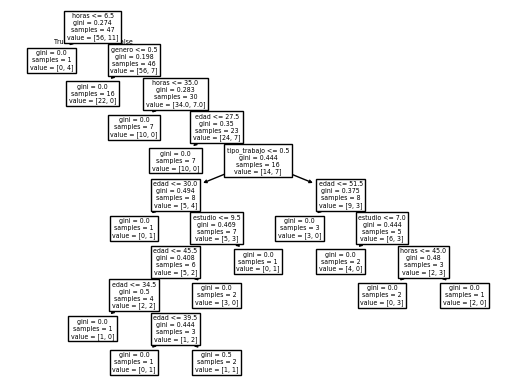

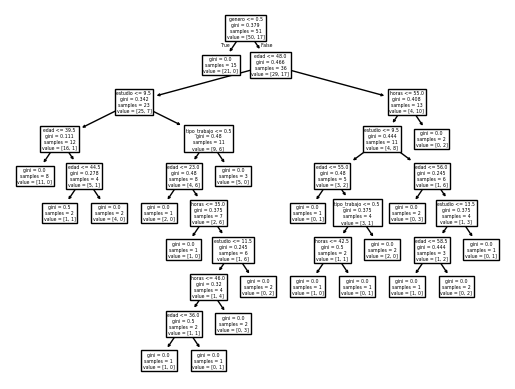

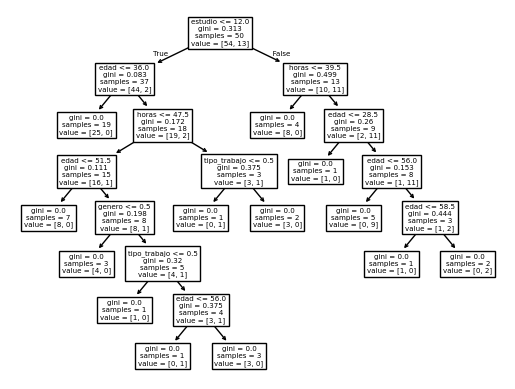

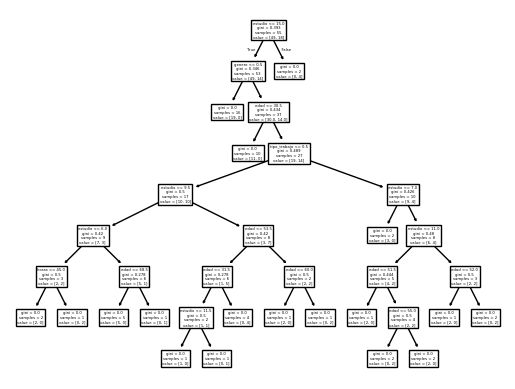

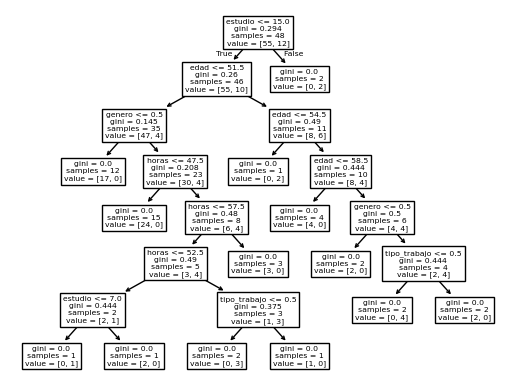

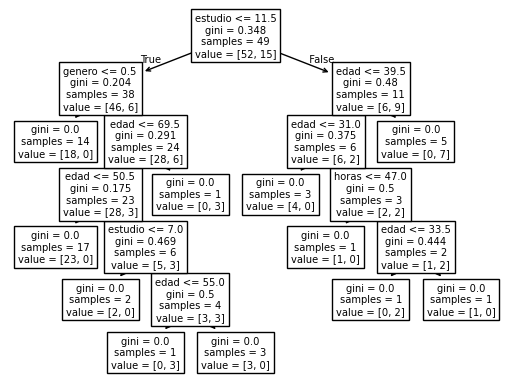

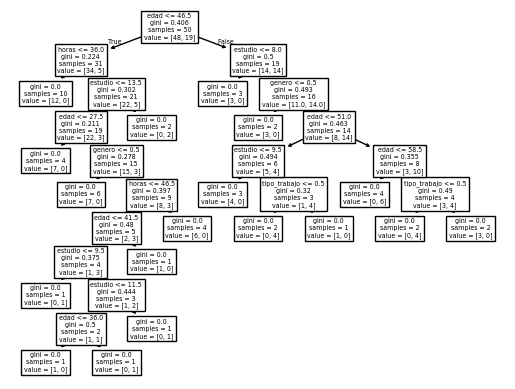

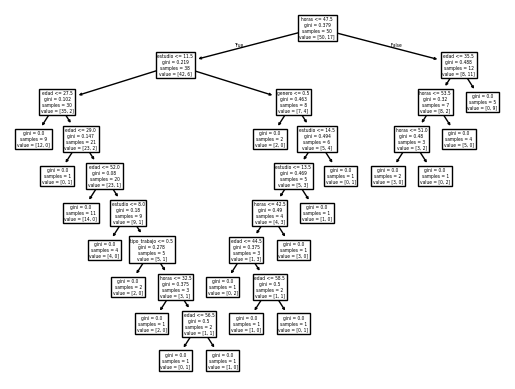

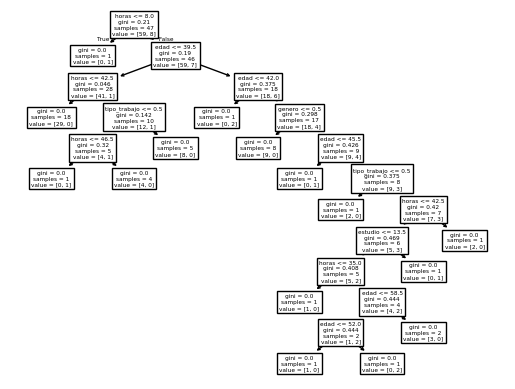

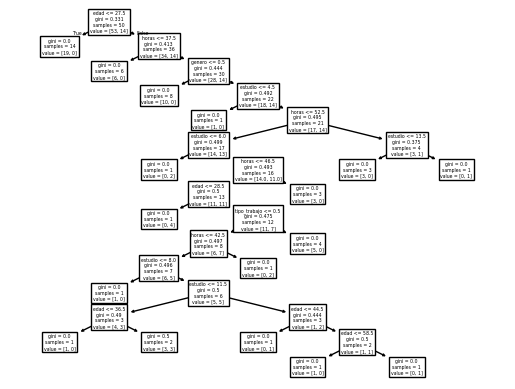

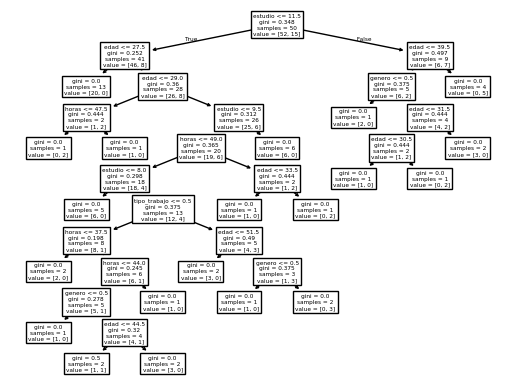

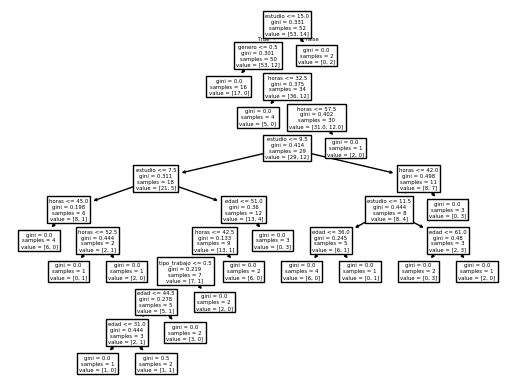

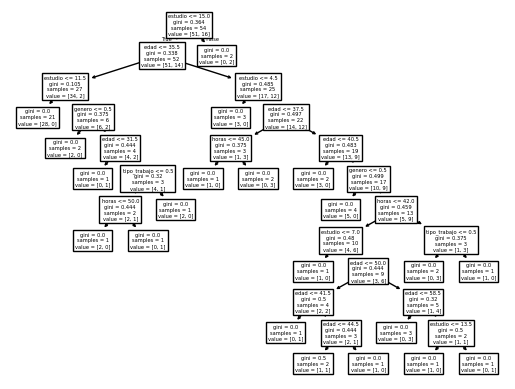

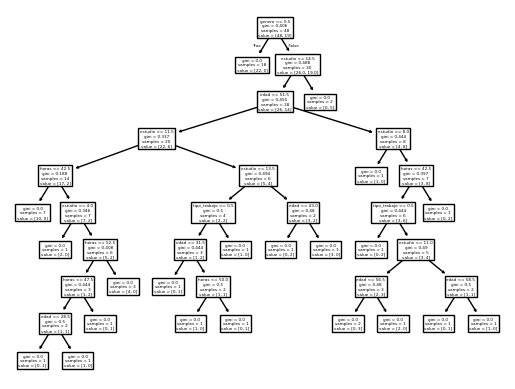

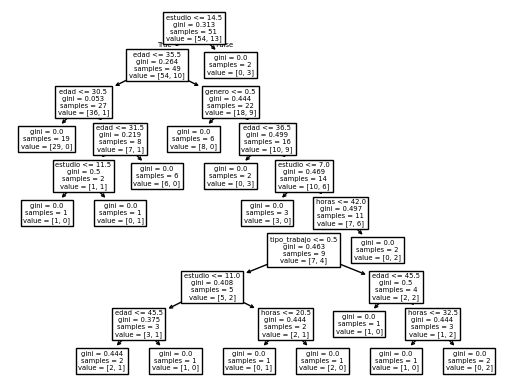

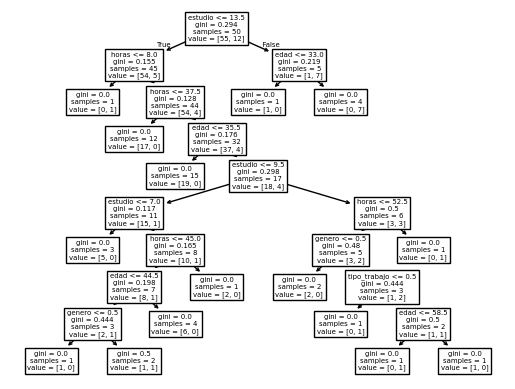

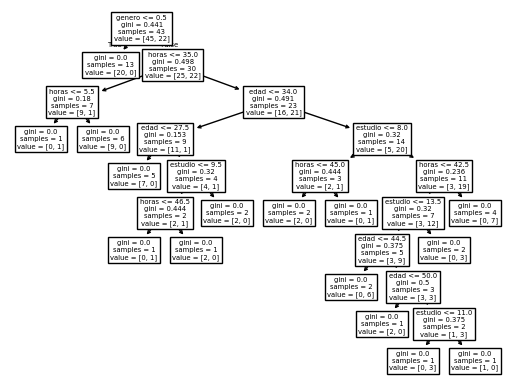

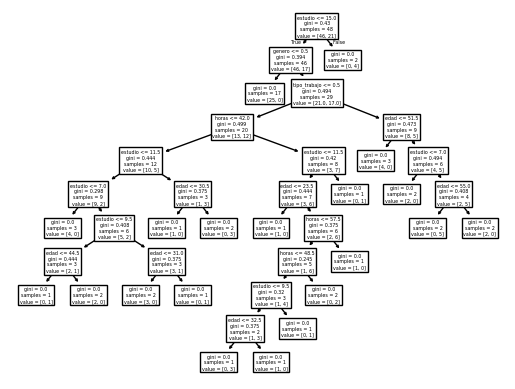

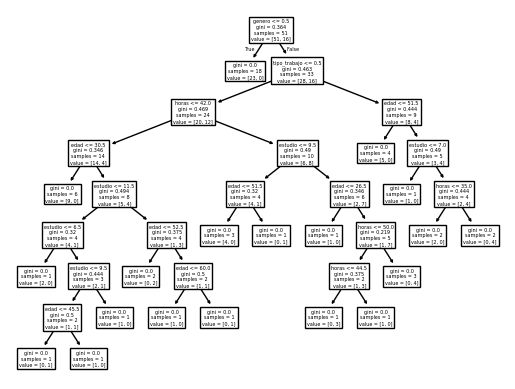

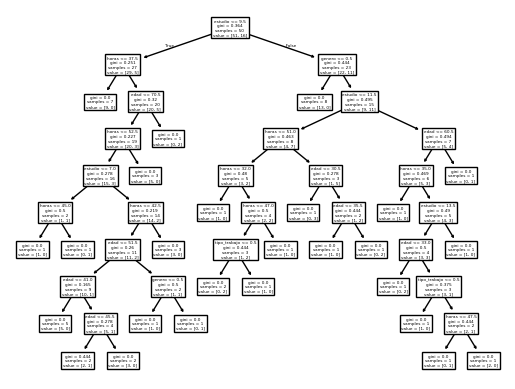

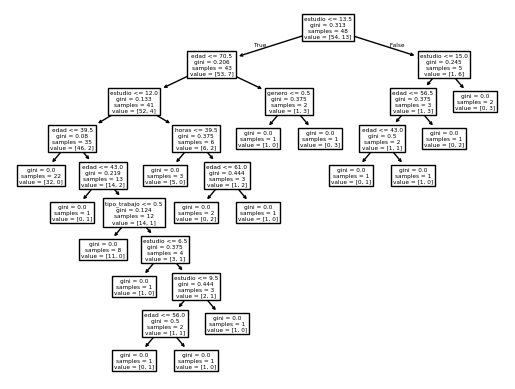

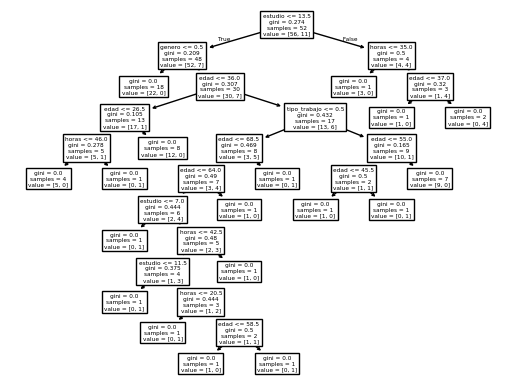

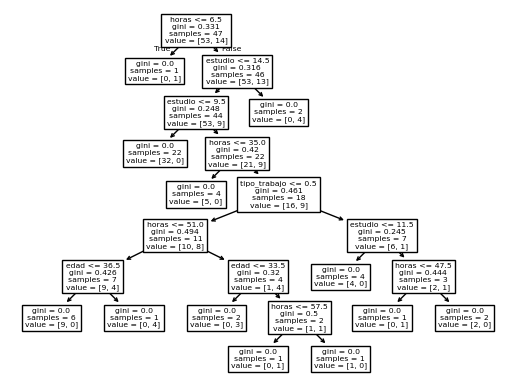

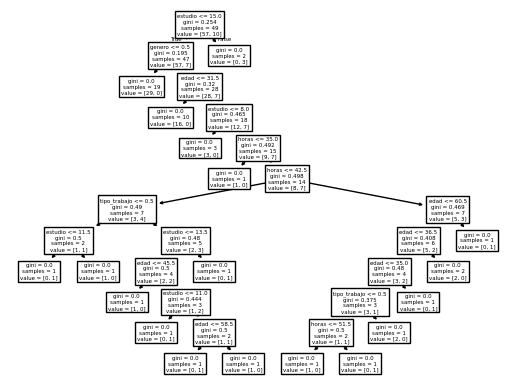

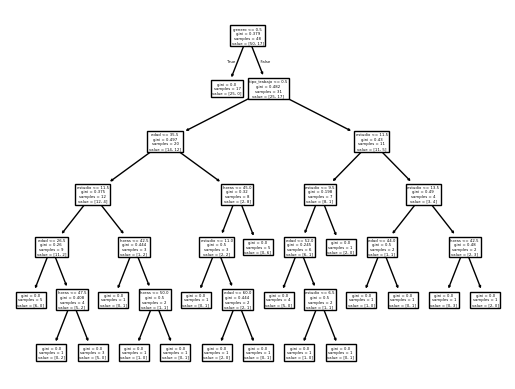

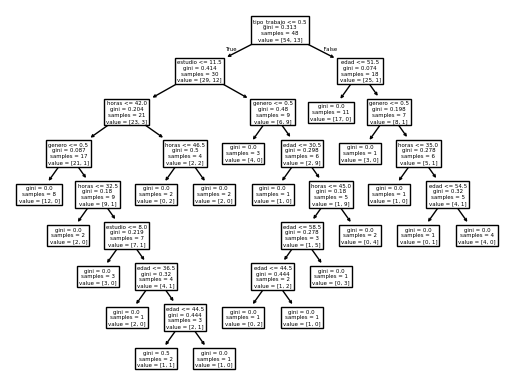

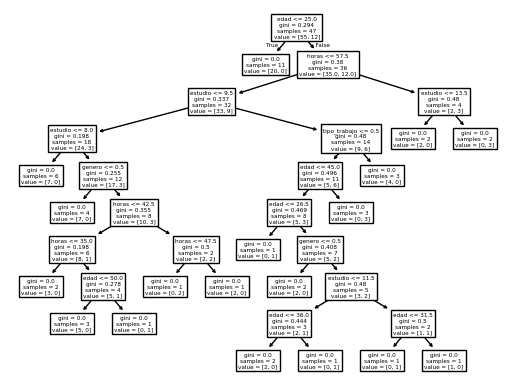

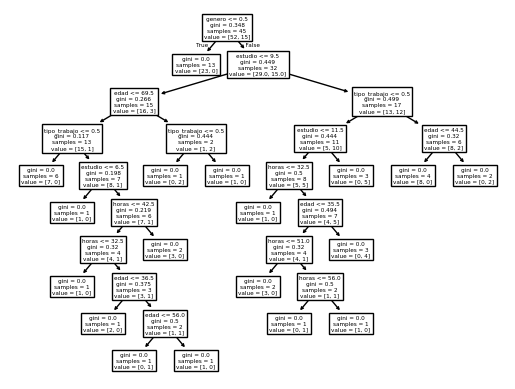

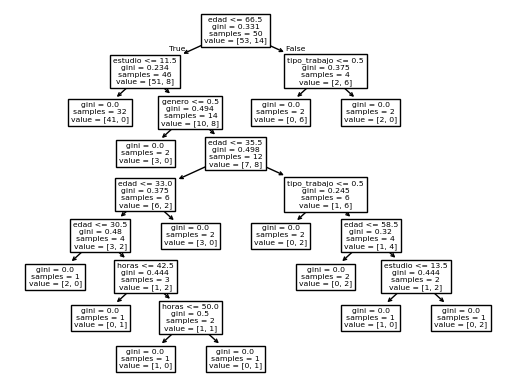

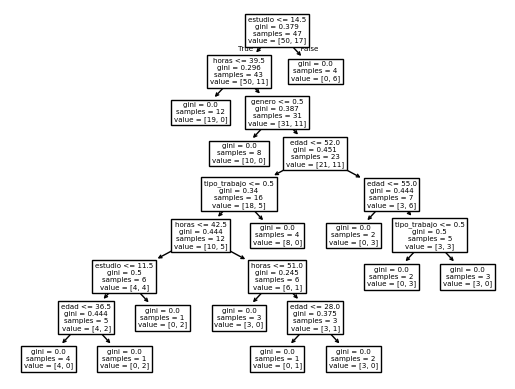

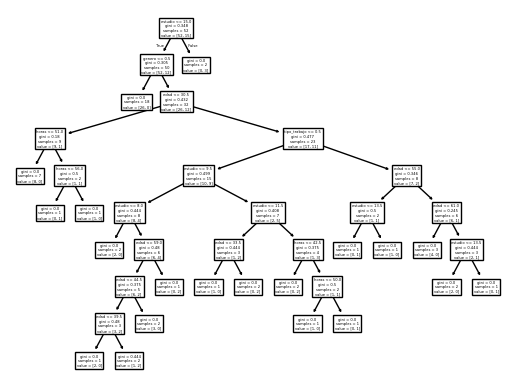

In [8]:
import matplotlib.pyplot as plt
from sklearn import tree

for arbol in bosque.estimators_:
    tree.plot_tree(arbol, feature_names=personas.columns[:-1])
    plt.show()